# Function-node activity gating

This tutorial demonstrates the `node_activity` feature of the GSNN. We simulate data from **two overlapping graphs** (shared inputs/outputs, but different function nodes). A single GSNN is trained on the union graph and receives a per-sample binary vector `x_fn` telling it which function nodes are active for that sample.

We compare two models:

1. **Model A** – plain GSNN (no node-activity gating)
2. **Model B** – GSNN with `node_activity=True`, conditioned on the binary `x_fn`

We then use `GSNNExplainer` to extract per-observation node importances and check, for one observation from each graph, whether the explainer's top-ranked function nodes align with the *true* set of function nodes used to generate that observation.

In [1]:
import networkx as nx
import numpy as np
import torch
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score

from gsnn.models.GSNN import GSNN
from gsnn.simulate.nx2pyg import nx2pyg
from gsnn.simulate.simulate import simulate
from gsnn.interpret import GSNNExplainer

%load_ext autoreload
%autoreload 2

torch.manual_seed(0)
np.random.seed(0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Define two overlapping graphs

Both graphs share the same input nodes (`in0..in2`), output nodes (`out0..out2`), and two shared function nodes (`fA`, `fB`). Each graph adds a pair of unique function nodes that route information differently.

The GSNN is constructed on the **union** of the two graphs so a single model architecture can represent both data-generating processes.

In [2]:
input_nodes  = ['in0', 'in1', 'in2']
output_nodes = ['out0', 'out1', 'out2']

shared_fns = ['fA', 'fB']
only_G1    = ['f1a', 'f1b']
only_G2    = ['f2a', 'f2b']
function_nodes = shared_fns + only_G1 + only_G2  # union ordering

# Graph 1: routes through fA/fB and the f1* nodes
G1 = nx.DiGraph()
G1.add_edges_from([
    ('in0', 'fA'),  ('in1', 'fB'),  ('in2', 'f1a'),
    ('fA',  'f1b'), ('fB',  'f1b'), ('f1a', 'f1b'),
    ('f1b', 'out0'), ('fA', 'out1'), ('fB', 'out2'),
])

# Graph 2: routes through fA/fB and the f2* nodes
G2 = nx.DiGraph()
G2.add_edges_from([
    ('in0', 'fA'),  ('in1', 'f2a'), ('in2', 'fB'),
    ('fA',  'f2b'), ('fB',  'f2b'), ('f2a', 'f2b'),
    ('f2b', 'out0'), ('fA', 'out1'), ('fB', 'out2'),
])

# Union graph used to build the GSNN (also ensures every node/edge appears)
G_union = nx.compose(G1, G2)
for n in input_nodes + function_nodes + output_nodes:
    G_union.add_node(n)

print(f"G1: {G1.number_of_nodes()} nodes, {G1.number_of_edges()} edges")
print(f"G2: {G2.number_of_nodes()} nodes, {G2.number_of_edges()} edges")
print(f"Union: {G_union.number_of_nodes()} nodes, {G_union.number_of_edges()} edges")
print(f"Function-node ordering: {function_nodes}")

G1: 10 nodes, 9 edges
G2: 10 nodes, 9 edges
Union: 12 nodes, 15 edges
Function-node ordering: ['fA', 'fB', 'f1a', 'f1b', 'f2a', 'f2b']


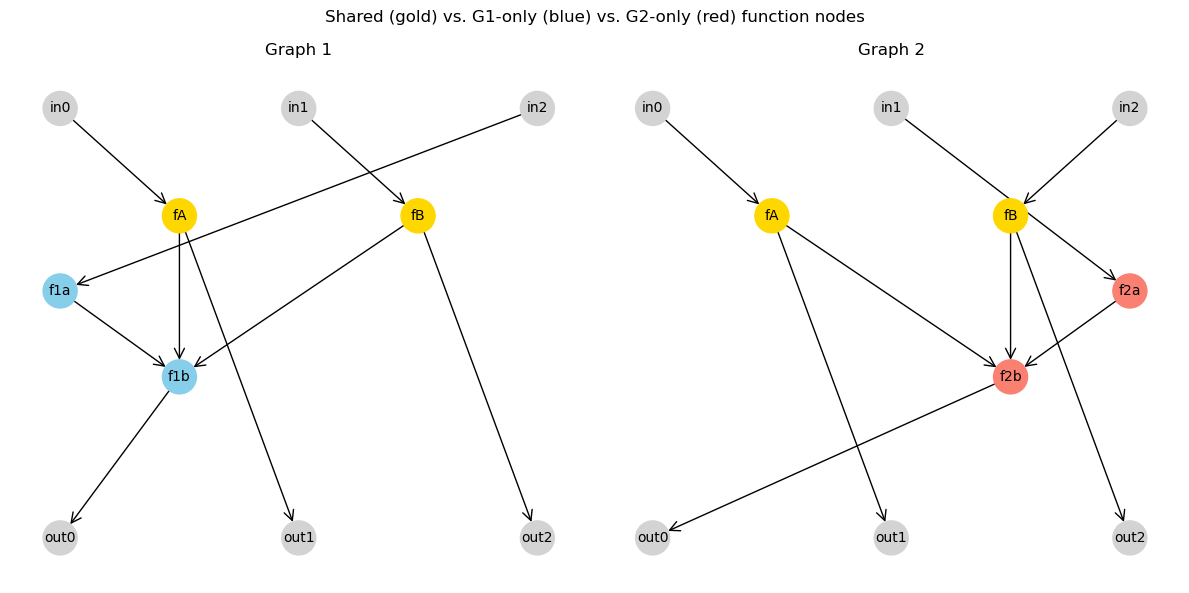

In [3]:
# Side-by-side plot of the two source graphs
pos = {
    'in0': (-2, 2),  'in1': (0, 2),  'in2': (2, 2),
    'fA':  (-1, 1),  'fB':  (1, 1),
    'f1a': (-2, 0.3),'f1b': (-1, -0.5),
    'f2a': (2, 0.3), 'f2b': (1, -0.5),
    'out0': (-2, -2),'out1': (0, -2), 'out2': (2, -2),
}

def color_for(n):
    if n in input_nodes:   return 'lightgray'
    if n in output_nodes:  return 'lightgray'
    if n in shared_fns:    return 'gold'
    if n in only_G1:       return 'skyblue'
    if n in only_G2:       return 'salmon'
    return 'white'

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, G, title in [(axes[0], G1, 'Graph 1'), (axes[1], G2, 'Graph 2')]:
    sub_pos = {n: pos[n] for n in G.nodes}
    colors = [color_for(n) for n in G.nodes]
    nx.draw_networkx(G, sub_pos, ax=ax, node_color=colors, with_labels=True,
                     node_size=600, font_size=10, arrowstyle='->', arrowsize=18)
    ax.set_title(title)
    ax.set_axis_off()
plt.suptitle('Shared (gold) vs. G1-only (blue) vs. G2-only (red) function nodes')
plt.tight_layout()
plt.show()

## Simulate data from each graph

We use the standard Bayesian-network simulator. A small set of per-graph `special_functions` ensures the two data-generating processes behave differently. For every sample we also record a length-`|function_nodes|` **binary mask** indicating which function nodes belong to the source graph (this is the `x_fn` input the node-activity model will use).

In [4]:
special_functions_G1 = {
    'fA':  lambda x: np.tanh(np.sum(x)),
    'fB':  lambda x: -np.mean(x),
    'f1a': lambda x: np.sum([xx**2 for xx in x]),
    'f1b': lambda x: np.tanh(np.sum(x)),
}

special_functions_G2 = {
    'fA':  lambda x: np.tanh(np.sum(x)),
    'fB':  lambda x: -np.mean(x),
    'f2a': lambda x: -np.sum([xx**2 for xx in x]),
    'f2b': lambda x: -np.tanh(np.sum(x)),
}

N_TRAIN = 400
N_TEST  = 100

x_tr_1, x_te_1, y_tr_1, y_te_1 = simulate(G1, n_train=N_TRAIN, n_test=N_TEST,
                                           input_nodes=input_nodes, output_nodes=output_nodes,
                                           special_functions=special_functions_G1, noise_scale=0.01)

x_tr_2, x_te_2, y_tr_2, y_te_2 = simulate(G2, n_train=N_TRAIN, n_test=N_TEST,
                                           input_nodes=input_nodes, output_nodes=output_nodes,
                                           special_functions=special_functions_G2, noise_scale=0.01)

print('G1 shapes:', x_tr_1.shape, y_tr_1.shape)
print('G2 shapes:', x_tr_2.shape, y_tr_2.shape)

G1 shapes: (400, 3) (400, 3)
G2 shapes: (400, 3) (400, 3)


In [5]:
# Per-graph function-node activity masks (1 = node present in that graph's subgraph)
def activity_vector(G_sub, function_nodes):
    present = set(G_sub.nodes)
    return np.array([1.0 if n in present else 0.0 for n in function_nodes], dtype=np.float32)

fn_mask_G1 = activity_vector(G1, function_nodes)
fn_mask_G2 = activity_vector(G2, function_nodes)

print('fn_mask_G1:', dict(zip(function_nodes, fn_mask_G1.astype(int))))
print('fn_mask_G2:', dict(zip(function_nodes, fn_mask_G2.astype(int))))

# Broadcast per-graph masks to per-sample masks
xfn_tr_1 = np.broadcast_to(fn_mask_G1, (N_TRAIN, len(function_nodes))).copy()
xfn_te_1 = np.broadcast_to(fn_mask_G1, (N_TEST,  len(function_nodes))).copy()
xfn_tr_2 = np.broadcast_to(fn_mask_G2, (N_TRAIN, len(function_nodes))).copy()
xfn_te_2 = np.broadcast_to(fn_mask_G2, (N_TEST,  len(function_nodes))).copy()

# Combine into one shuffled train set and one stacked test set (graph 1 first, then graph 2)
rng = np.random.default_rng(0)
perm = rng.permutation(2 * N_TRAIN)

def to_tensor(a):
    return torch.tensor(a, dtype=torch.float32, device=device)

x_train   = to_tensor(np.concatenate([x_tr_1, x_tr_2], axis=0)[perm])
y_train   = to_tensor(np.concatenate([y_tr_1, y_tr_2], axis=0)[perm])
xfn_train = to_tensor(np.concatenate([xfn_tr_1, xfn_tr_2], axis=0)[perm])

x_test    = to_tensor(np.concatenate([x_te_1, x_te_2], axis=0))
y_test    = to_tensor(np.concatenate([y_te_1, y_te_2], axis=0))
xfn_test  = to_tensor(np.concatenate([xfn_te_1, xfn_te_2], axis=0))

# Track which source graph each test row came from (for later evaluation)
test_source = np.array(['G1'] * N_TEST + ['G2'] * N_TEST)

print('Combined train:', x_train.shape, y_train.shape, xfn_train.shape)
print('Combined test :', x_test.shape,  y_test.shape,  xfn_test.shape)

fn_mask_G1: {'fA': 1, 'fB': 1, 'f1a': 1, 'f1b': 1, 'f2a': 0, 'f2b': 0}
fn_mask_G2: {'fA': 1, 'fB': 1, 'f1a': 0, 'f1b': 0, 'f2a': 1, 'f2b': 1}
Combined train: torch.Size([800, 3]) torch.Size([800, 3]) torch.Size([800, 6])
Combined test : torch.Size([200, 3]) torch.Size([200, 3]) torch.Size([200, 6])


## Train two GSNNs on the combined dataset

- **Model A** sees only `x`. It cannot distinguish which source graph a sample came from, so it has to learn an average behaviour over both.
- **Model B** sees `x` *and* the binary `x_fn` mask. The `NodeActivity` module produces a per-function-node gate (one scalar per node, shared across all layers).

Hyperparameters are otherwise identical.

In [13]:
data = nx2pyg(G_union, input_nodes, function_nodes, output_nodes)

gsnn_kwargs = dict(
    channels=5,
    layers=3,
    share_layers=False,
    bias=True,
    add_function_self_edges=False,
    checkpoint=False,
    norm='none',
    init='degree_normalized',
    residual=True,
    node_attn=False,
    node_mlp=False,
    dropout=0.,
)

def train(model, with_xfn, n_iters=1000, lr=1e-2, weight_decay=1e-2):
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit  = torch.nn.MSELoss()
    for i in range(n_iters):
        model.train(); optim.zero_grad()
        if with_xfn:
            yhat = model(x_train, x_fn=xfn_train)
        else:
            yhat = model(x_train)
        loss = crit(y_train, yhat)
        loss.backward()
        optim.step()
        if (i + 1) % 100 == 0 or i == n_iters - 1:
            model.eval()
            with torch.no_grad():
                if with_xfn:
                    yhat_te = model(x_test, x_fn=xfn_test)
                else:
                    yhat_te = model(x_test)
                te_loss = crit(y_test, yhat_te).item()
            print(f'  iter {i + 1:4d} | train mse: {loss.item():.4f} | test mse: {te_loss:.4f}', end='\r')
    print()
    return model

In [14]:
print('Training Model A (no node activity)...')
torch.manual_seed(0)
model_A = GSNN(data.edge_index_dict, data.node_names_dict,
               node_activity=False, **gsnn_kwargs).to(device)
train(model_A, with_xfn=False)

print('Training Model B (with node activity)...')
torch.manual_seed(0)
model_B = GSNN(data.edge_index_dict, data.node_names_dict,
               node_activity=True,
               node_activity_dim=1,
               node_activity_hidden=16,
               node_activity_temperature=0.5,
               **gsnn_kwargs).to(device)
train(model_B, with_xfn=True)

print('Model A params:', sum(p.numel() for p in model_A.parameters()))
print('Model B params:', sum(p.numel() for p in model_B.parameters()))

Training Model A (no node activity)...
  iter 1000 | train mse: 0.2516 | test mse: 0.2494
Training Model B (with node activity)...
  iter 1000 | train mse: 0.1590 | test mse: 0.1566
Model A params: 453
Model B params: 534


### Test performance

Model A (no node activity): test MSE = 0.2494 | Pearson r = 0.7756
Model B (with node activity): test MSE = 0.1566 | Pearson r = 0.8659


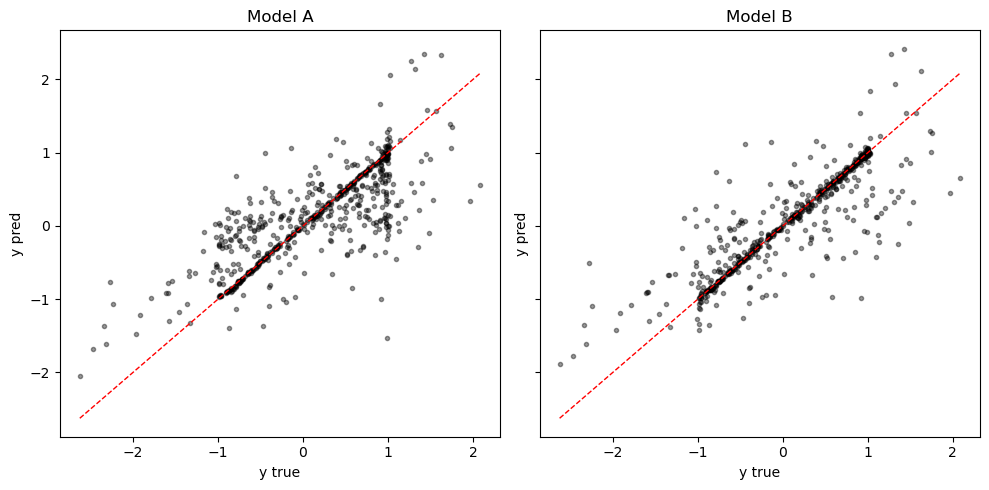

In [15]:
model_A.eval(); model_B.eval()
with torch.no_grad():
    yhat_A = model_A(x_test).cpu().numpy()
    yhat_B = model_B(x_test, x_fn=xfn_test).cpu().numpy()
y_true = y_test.cpu().numpy()

def report(name, yhat):
    mse = float(np.mean((y_true - yhat) ** 2))
    r   = float(np.corrcoef(y_true.ravel(), yhat.ravel())[0, 1])
    print(f'{name}: test MSE = {mse:.4f} | Pearson r = {r:.4f}')

report('Model A (no node activity)', yhat_A)
report('Model B (with node activity)', yhat_B)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
for ax, name, yhat in [(axes[0], 'Model A', yhat_A), (axes[1], 'Model B', yhat_B)]:
    ax.plot(y_true.ravel(), yhat.ravel(), 'k.', alpha=0.4)
    lo, hi = y_true.min(), y_true.max()
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_title(name); ax.set_xlabel('y true'); ax.set_ylabel('y pred')
plt.tight_layout()
plt.show()

## Per-observation node importances

We pick one test observation from each source graph and run `GSNNExplainer` to extract per-node importance scores. For Model B we forward `x_fn` to the underlying GSNN through the explainer's new `model_kwargs` hook.

**Ground truth:** for an observation drawn from graph `G_i`, the *true* set of "important" function nodes is the set of function nodes that appear in `G_i` *and* lie on some input→output path. Function nodes that are only in the other graph should receive low scores.

In [16]:
# Pick one observation from each source graph
idx_1 = 0                     # first row in test set came from G1
idx_2 = N_TEST                # first row from G2

obs_1     = x_test[idx_1:idx_1 + 1]
obs_2     = x_test[idx_2:idx_2 + 1]
xfn_obs_1 = xfn_test[idx_1:idx_1 + 1]
xfn_obs_2 = xfn_test[idx_2:idx_2 + 1]

# Ground-truth active function nodes per graph: those reachable on an input->output path
def active_function_nodes(G_sub, input_nodes, output_nodes, function_nodes):
    reachable_from_inputs = set()
    for s in input_nodes:
        if s in G_sub:
            reachable_from_inputs |= nx.descendants(G_sub, s)
    can_reach_outputs = set()
    for t in output_nodes:
        if t in G_sub:
            can_reach_outputs |= nx.ancestors(G_sub, t)
    active = reachable_from_inputs & can_reach_outputs
    return [n for n in function_nodes if n in active]

active_G1 = active_function_nodes(G1, input_nodes, output_nodes, function_nodes)
active_G2 = active_function_nodes(G2, input_nodes, output_nodes, function_nodes)

print('Active function nodes in G1:', active_G1)
print('Active function nodes in G2:', active_G2)

Active function nodes in G1: ['fA', 'fB', 'f1a', 'f1b']
Active function nodes in G2: ['fA', 'fB', 'f2a', 'f2b']


In [28]:
EXPLAINER_KWARGS = dict(iters=300, beta=1e-2, lr=1e-2, prior=1.0, verbose=True)

def explain_node(model, obs, model_kwargs=None):
    expl = GSNNExplainer(model, data, **EXPLAINER_KWARGS)
    return expl.explain(obs, target='node', model_kwargs=model_kwargs)

node_df_A_1 = explain_node(model_A, obs_1)
node_df_A_2 = explain_node(model_A, obs_2)
node_df_B_1 = explain_node(model_B, obs_1, model_kwargs={'x_fn': xfn_obs_1})
node_df_B_2 = explain_node(model_B, obs_2, model_kwargs={'x_fn': xfn_obs_2})

print('Top-5 nodes per (model, observation):')
for name, df in [('A | obs from G1', node_df_A_1), ('A | obs from G2', node_df_A_2),
                 ('B | obs from G1', node_df_B_1), ('B | obs from G2', node_df_B_2)]:
    top = df.sort_values('score', ascending=False).head(5)
    print(f'  {name:>20}: ' + ', '.join(f'{n}={s:.2f}' for n, s in zip(top['node'], top['score'])))

iter: 299 | loss: 0.1118 | mse: 0.0447 | r2: 0.933 | active nodes: 7 / 12 | entropy: 0.21276
POST-TRAINING EVALUATION (nodes > 0.5)
Selected nodes: 6 / 12 (50.0%)
MSE (subset): 0.000000
R² (subset): 1.0000
iter: 299 | loss: 0.0545 | mse: 0.0045 | r2: 0.993 | active nodes: 5 / 12 | entropy: 0.2081
POST-TRAINING EVALUATION (nodes > 0.5)
Selected nodes: 4 / 12 (33.3%)
MSE (subset): 0.061055
R² (subset): 0.9664
iter: 299 | loss: 0.0430 | mse: 0.0001 | r2: 1.000 | active nodes: 5 / 12 | entropy: 0.18669
POST-TRAINING EVALUATION (nodes > 0.5)
Selected nodes: 3 / 12 (25.0%)
MSE (subset): 0.000103
R² (subset): 0.9998
iter: 299 | loss: 0.0401 | mse: 0.0000 | r2: 1.000 | active nodes: 4 / 12 | entropy: 0.12375
POST-TRAINING EVALUATION (nodes > 0.5)
Selected nodes: 4 / 12 (33.3%)
MSE (subset): 0.000000
R² (subset): 1.0000
Top-5 nodes per (model, observation):
       A | obs from G1: fA=0.99, f1b=0.97, f2b=0.96, f1a=0.92, fB=0.85
       A | obs from G2: fA=0.99, fB=0.99, f2a=0.90, f2b=0.88, f1b=0.

In [29]:
# Quantitative comparison: restrict to function nodes (inputs/outputs are not part of the ground truth)
def fn_scores(df):
    sub = df[df['node'].isin(function_nodes)].set_index('node').reindex(function_nodes)
    return sub['score'].to_numpy()

def precision_at_k(scores, truth_mask, k):
    order = np.argsort(-scores)
    return float(truth_mask[order[:k]].mean())

def auroc(scores, truth_mask):
    if truth_mask.sum() in (0, len(truth_mask)):
        return float('nan')
    return float(roc_auc_score(truth_mask, scores))

def evaluate(df, active_set):
    scores = fn_scores(df)
    truth  = np.array([1 if n in active_set else 0 for n in function_nodes], dtype=int)
    k      = int(truth.sum())
    return {
        'precision@k': precision_at_k(scores, truth, k),
        'AUROC':       auroc(scores, truth),
        'k':           k,
    }

rows = []
for label, df, active in [
    ('A | obs from G1', node_df_A_1, active_G1),
    ('A | obs from G2', node_df_A_2, active_G2),
    ('B | obs from G1', node_df_B_1, active_G1),
    ('B | obs from G2', node_df_B_2, active_G2),
]:
    m = evaluate(df, active)
    rows.append((label, m['k'], m['precision@k'], m['AUROC']))

print(f'{"setting":>20} | {"k":>2} | {"prec@k":>7} | {"AUROC":>6}')
print('-' * 48)
for label, k, p, a in rows:
    print(f'{label:>20} | {k:>2d} | {p:>7.3f} | {a:>6.3f}')

             setting |  k |  prec@k |  AUROC
------------------------------------------------
     A | obs from G1 |  4 |   0.750 |  0.750
     A | obs from G2 |  4 |   1.000 |  1.000
     B | obs from G1 |  4 |   1.000 |  1.000
     B | obs from G2 |  4 |   1.000 |  1.000


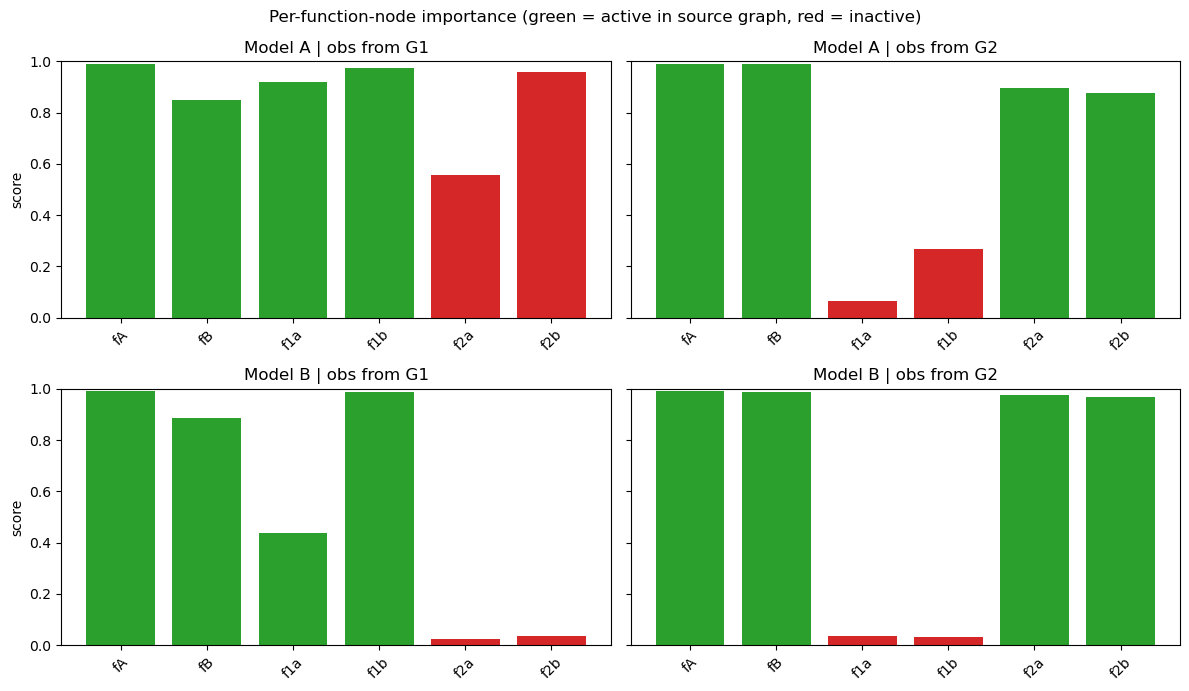

In [30]:
# Bar plot: per-function-node scores, colored by ground truth membership in the source graph
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
panels = [
    (axes[0, 0], node_df_A_1, active_G1, 'Model A | obs from G1'),
    (axes[0, 1], node_df_A_2, active_G2, 'Model A | obs from G2'),
    (axes[1, 0], node_df_B_1, active_G1, 'Model B | obs from G1'),
    (axes[1, 1], node_df_B_2, active_G2, 'Model B | obs from G2'),
]
for ax, df, active, title in panels:
    scores = fn_scores(df)
    colors = ['tab:green' if n in active else 'tab:red' for n in function_nodes]
    ax.bar(function_nodes, scores, color=colors)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
axes[0, 0].set_ylabel('score')
axes[1, 0].set_ylabel('score')
fig.suptitle('Per-function-node importance (green = active in source graph, red = inactive)')
plt.tight_layout()
plt.show()

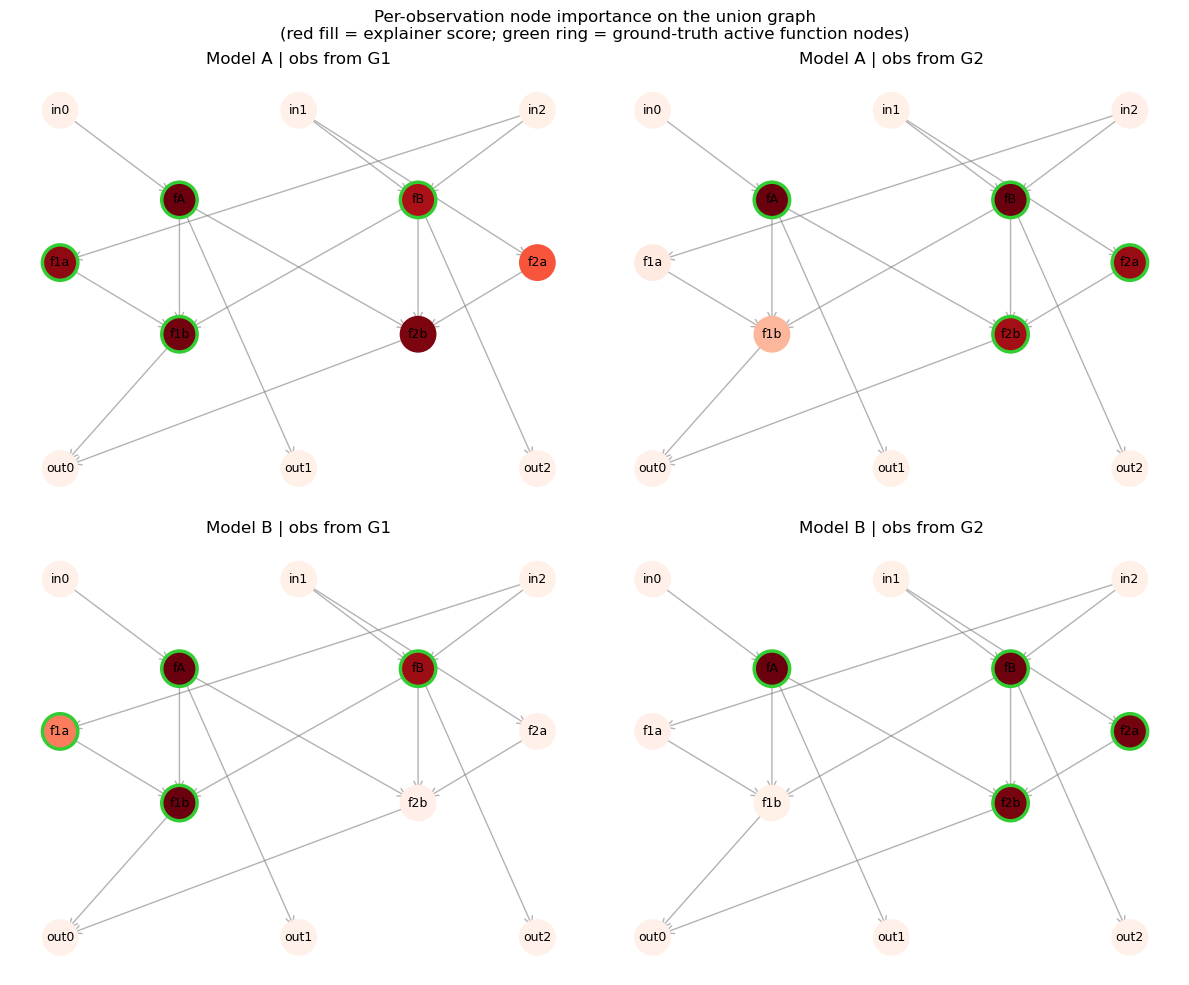

In [31]:
# Same four explanations rendered on the union-graph topology.
# Node fill = explainer score (red shade), green outline = ground-truth active in source graph.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
panels = [
    (axes[0, 0], node_df_A_1, 'Model A | obs from G1', active_G1),
    (axes[0, 1], node_df_A_2, 'Model A | obs from G2', active_G2),
    (axes[1, 0], node_df_B_1, 'Model B | obs from G1', active_G1),
    (axes[1, 1], node_df_B_2, 'Model B | obs from G2', active_G2),
]
for ax, df, title, active in panels:
    score_map = dict(zip(df['node'], df['score']))
    node_colors = [score_map.get(n, 0.0) for n in G_union.nodes]
    nx.draw_networkx_edges(G_union, pos, ax=ax, arrowstyle='->', arrowsize=15,
                           edge_color='gray', alpha=0.6)
    nx.draw_networkx_labels(G_union, pos, ax=ax, font_size=9)
    nx.draw_networkx_nodes(G_union, pos, ax=ax, nodelist=list(G_union.nodes),
                           node_color=node_colors, cmap=plt.cm.Reds,
                           vmin=0, vmax=1, node_size=650)
    active_in_graph = [n for n in active if n in G_union.nodes]
    if active_in_graph:
        nx.draw_networkx_nodes(G_union, pos, ax=ax, nodelist=active_in_graph,
                               node_color='none', edgecolors='limegreen',
                               linewidths=2.5, node_size=650)
    ax.set_title(title)
    ax.set_axis_off()
plt.suptitle('Per-observation node importance on the union graph\n'
             '(red fill = explainer score; green ring = ground-truth active function nodes)')
plt.tight_layout()
plt.show()

## Predicted function-node activities (Model B)

We can also inspect the gates that `NodeActivity` produces directly. For each sample the module runs the binary `x_fn` through a small MLP and a sigmoid to yield one scalar `alpha` per function node, which is then broadcast across that node's channels at every layer.

A well-trained gate should output `alpha ≈ 1` for function nodes that are *active* in the source graph and `alpha ≈ 0` for the ones that are not. Below we plot the predicted `alpha` next to the input mask for one observation from each graph.

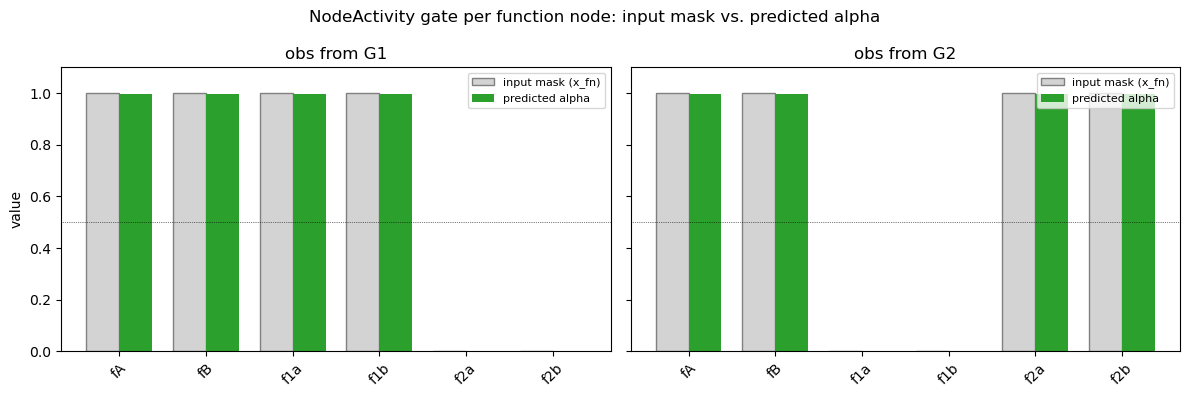

In [32]:
# Extract per-function-node alpha from NodeActivity.
# NodeActivity returns (B, Nf*C_pn) by broadcasting alpha across each node's channels,
# so the per-node gate is recovered by reshaping and taking any channel slot.
nact = model_B.node_activity_model
nact.eval()
with torch.no_grad():
    raw_1 = nact(xfn_obs_1).view(1, nact.n_nodes, nact.channels_per_node)
    raw_2 = nact(xfn_obs_2).view(1, nact.n_nodes, nact.channels_per_node)
    alpha_1 = raw_1[0, :, 0].cpu().numpy()
    alpha_2 = raw_2[0, :, 0].cpu().numpy()

assert nact.n_nodes == len(function_nodes), (
    f"NodeActivity expects {nact.n_nodes} function nodes, notebook uses {len(function_nodes)}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
panels = [
    (axes[0], alpha_1, xfn_obs_1[0].cpu().numpy(), 'obs from G1', active_G1),
    (axes[1], alpha_2, xfn_obs_2[0].cpu().numpy(), 'obs from G2', active_G2),
]
xpos = np.arange(len(function_nodes))
width = 0.38
for ax, alpha, mask, title, active in panels:
    bar_colors = ['tab:green' if n in active else 'tab:red' for n in function_nodes]
    ax.bar(xpos - width / 2, mask, width=width, color='lightgray',
           edgecolor='gray', label='input mask (x_fn)')
    ax.bar(xpos + width / 2, alpha, width=width, color=bar_colors,
           label='predicted alpha')
    ax.axhline(0.5, color='k', lw=0.5, ls=':')
    ax.set_xticks(xpos)
    ax.set_xticklabels(function_nodes, rotation=45)
    ax.set_ylim(0, 1.1)
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
axes[0].set_ylabel('value')
fig.suptitle('NodeActivity gate per function node: input mask vs. predicted alpha')
plt.tight_layout()
plt.show()

## Takeaways

- **Predictive performance:** Model B (with `node_activity`) typically achieves lower test MSE because the binary `x_fn` mask lets a single GSNN cleanly separate the two data-generating processes; Model A has to average over both.
- **Node importances:** Because Model B's `NodeActivity` gates suppress channels of function nodes that are not active in a given sample, the explainer is forced to attribute predictions only to the *active* subset. Model A has no such mechanism, so its node importances tend to spread across function nodes from both source graphs, lowering precision@k and AUROC against the ground-truth active set.

This is the simplest possible demonstration — the same setup can be extended to richer per-node features (`node_activity_dim > 1`), more than two graphs, or more realistic biology-inspired pathways.